# 1D-CNN for Incident Classification

This notebook trains and evaluates a **1D-CNN** for the fixed three-class task:

- `NORMAL`
- `ACCIDENT`
- `OTHER_DISRUPTION`

It uses the same revised canonical dataset with two frozen evaluation settings:

1. **Grouped-random split**
2. **Spatial split (unseen stations)**

The primary model-selection metric is **validation Macro-F1**. The test set is evaluated only after the best hyperparameters have been selected.

> `all_zero_flow_window`, identifiers, station IDs, timestamps, and target-derived columns are retained only for auditing and are not used as predictors.

In [4]:
# Optional installation if needed:
# !pip install pandas numpy scikit-learn matplotlib torch

from pathlib import Path
import random
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_recall_fscore_support,
)
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)

SEEDS = [42, 52, 62]
CLASS_ORDER = ["NORMAL", "ACCIDENT", "OTHER_DISRUPTION"]
CLASS_TO_INDEX = {label: i for i, label in enumerate(CLASS_ORDER)}
INDEX_TO_CLASS = {i: label for label, i in CLASS_TO_INDEX.items()}

MAX_EPOCHS = 35
BATCH_SIZE = 64
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
PATIENCE = 6
DROPOUT = 0.2
GRAD_CLIP = 1.0

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Change only DATA_DIR if your files are stored elsewhere.
DATA_DIR = Path(".")

def resolve_file(*candidate_names):
    for name in candidate_names:
        path = DATA_DIR / name
        if path.exists():
            return path
    raise FileNotFoundError(
        "Could not find any expected filename. Place this notebook in the same "
        "folder as the three CSV files or update DATA_DIR."
    )

CANONICAL_PATH = resolve_file(
    "canonical_dataset_revised.csv",
    "canonical_dataset_revised(2).csv",
)
GROUPED_MANIFEST_PATH = resolve_file(
    "grouped_random_split_manifest_revised.csv",
    "grouped_random_split_manifest_revised(2).csv",
)
SPATIAL_MANIFEST_PATH = resolve_file(
    "spatial_split_manifest_revised.csv",
    "spatial_split_manifest_revised(2).csv",
)

OUTPUT_DIR = DATA_DIR / "cnn_1d_outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Device:", DEVICE)
print("Canonical:", CANONICAL_PATH.resolve())
print("Grouped manifest:", GROUPED_MANIFEST_PATH.resolve())
print("Spatial manifest:", SPATIAL_MANIFEST_PATH.resolve())
print("Output directory:", OUTPUT_DIR.resolve())

Device: cpu
Canonical: D:\Dokumen\KULIAH\DATA5925\Traffic-Benchmark\canonical_dataset_revised.csv
Grouped manifest: D:\Dokumen\KULIAH\DATA5925\Traffic-Benchmark\grouped_random_split_manifest_revised.csv
Spatial manifest: D:\Dokumen\KULIAH\DATA5925\Traffic-Benchmark\spatial_split_manifest_revised.csv
Output directory: D:\Dokumen\KULIAH\DATA5925\Traffic-Benchmark\cnn_1d_outputs


## 1. Load and validate the fixed data

In [5]:
canonical = pd.read_csv(CANONICAL_PATH)
grouped_manifest = pd.read_csv(GROUPED_MANIFEST_PATH)
spatial_manifest = pd.read_csv(SPATIAL_MANIFEST_PATH)

print("Canonical shape:", canonical.shape)
print("Grouped manifest shape:", grouped_manifest.shape)
print("Spatial manifest shape:", spatial_manifest.shape)

print("\nClass distribution:")
display(
    canonical["target_class"]
    .value_counts()
    .reindex(CLASS_ORDER)
    .to_frame("count")
)

assert canonical["event_sample_id"].is_unique, "Duplicate event_sample_id in canonical dataset."
assert grouped_manifest["event_sample_id"].is_unique, "Duplicate event_sample_id in grouped manifest."
assert spatial_manifest["event_sample_id"].is_unique, "Duplicate event_sample_id in spatial manifest."

assert set(canonical["event_sample_id"]) == set(grouped_manifest["event_sample_id"]), "Grouped manifest mismatch."
assert set(canonical["event_sample_id"]) == set(spatial_manifest["event_sample_id"]), "Spatial manifest mismatch."

assert set(canonical["target_class"].unique()) == set(CLASS_ORDER), "Unexpected target classes."
assert set(grouped_manifest["split"].unique()) == {"train", "validation", "test"}
assert set(spatial_manifest["split"].unique()) == {"train", "validation", "test"}

for name, manifest in [("Grouped-random", grouped_manifest), ("Spatial", spatial_manifest)]:
    check = canonical[["event_sample_id", "target_class"]].merge(
        manifest[["event_sample_id", "target_class"]],
        on="event_sample_id",
        suffixes=("_canonical", "_manifest"),
        validate="one_to_one",
    )
    assert (
        check["target_class_canonical"] == check["target_class_manifest"]
    ).all(), f"Target mismatch in {name} manifest."

station_split_counts = spatial_manifest.groupby("station_id")["split"].nunique()
assert station_split_counts.max() == 1, "Spatial leakage: a station appears in multiple partitions."

print("\nAll integrity checks passed.")
print("Spatial station-disjointness check passed.")

Canonical shape: (5265, 16)
Grouped manifest shape: (5265, 5)
Spatial manifest shape: (5265, 5)

Class distribution:


,count
target_class,
NORMAL,3581
ACCIDENT,505
OTHER_DISRUPTION,1179



All integrity checks passed.
Spatial station-disjointness check passed.


## 2. Build the 2 × 7 Sequence Representation

The seven-hour window is:

$$
[t-3,\ t-2,\ t-1,\ t_0,\ t+1,\ t+2,\ t+3]
$$

### Channel 1: Measured Log-Flow

$$
x_1(t) = \log(1 + \mathrm{flow}(t))
$$

### Channel 2: Pre-Event-Normalized Relative Change

The baseline is calculated as the median of the three pre-event flow observations:

$$
B = \mathrm{median}
\left(
\mathrm{flow}_{t-3},
\mathrm{flow}_{t-2},
\mathrm{flow}_{t-1}
\right)
$$

The relative change at each timestep is then calculated as:

$$
x_2(t) =
\frac{\mathrm{flow}(t) - B}
{B + 1}
$$

The relative-change channel is clipped to the range:

$$
[-5,\ 5]
$$

The final input shape for the 1D-CNN is:

$$
(N,\ 2,\ 7)
$$

where:

- **N** = number of samples
- **2** = number of input channels
- **7** = number of hourly timesteps

Scaling is fitted using the **training partition only** and then applied unchanged to the validation and test partitions.

In [6]:
FLOW_COLS = [
    "flow_t_minus_3",
    "flow_t_minus_2",
    "flow_t_minus_1",
    "flow_t0",
    "flow_t_plus_1",
    "flow_t_plus_2",
    "flow_t_plus_3",
]

def build_raw_sequence(df):
    missing = [c for c in FLOW_COLS if c not in df.columns]
    if missing:
        raise ValueError(f"Missing flow columns: {missing}")

    flow = df[FLOW_COLS].astype(float).to_numpy()

    if not np.isfinite(flow).all():
        raise ValueError("Flow matrix contains NaN or infinite values.")
    if (flow < 0).any():
        raise ValueError("Negative flow values found.")

    log_flow = np.log1p(flow)

    baseline = np.median(flow[:, :3], axis=1, keepdims=True)
    relative_change = (flow - baseline) / (baseline + 1.0)
    relative_change = np.clip(relative_change, -5.0, 5.0)

    sequence = np.stack(
        [log_flow, relative_change],
        axis=1,
    ).astype(np.float32)

    return sequence

def fit_channel_scalers(X_train):
    scalers = []
    for channel_idx in range(X_train.shape[1]):
        scaler = StandardScaler()
        scaler.fit(X_train[:, channel_idx, :].reshape(-1, 1))
        scalers.append(scaler)
    return scalers

def apply_channel_scalers(X, scalers):
    X_scaled = X.copy().astype(np.float32)

    for channel_idx, scaler in enumerate(scalers):
        shape = X_scaled[:, channel_idx, :].shape
        X_scaled[:, channel_idx, :] = scaler.transform(
            X_scaled[:, channel_idx, :].reshape(-1, 1)
        ).reshape(shape)

    return X_scaled.astype(np.float32)

X_preview = build_raw_sequence(canonical)

print("Raw CNN sequence shape:", X_preview.shape)
print("Expected: (samples, 2 channels, 7 timesteps)")

print("\nFirst sample:")
print("Class:", canonical.loc[0, "target_class"])
print("Log-flow channel:", np.round(X_preview[0, 0], 3))
print("Relative-change channel:", np.round(X_preview[0, 1], 3))

Raw CNN sequence shape: (5265, 2, 7)
Expected: (samples, 2 channels, 7 timesteps)

First sample:
Class: OTHER_DISRUPTION
Log-flow channel: [0. 0. 0. 0. 0. 0. 0.]
Relative-change channel: [0. 0. 0. 0. 0. 0. 0.]


## 3. Prepare the frozen split data

For each split scheme, this section:

- merges the canonical dataset with the manifest;
- creates train, validation, and test tensors;
- fits scalers on training data only;
- encodes the three class labels;
- computes class weights from the training partition.

In [7]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

def merge_split(canonical_df, manifest):
    manifest_small = manifest[["event_sample_id", "target_class", "split"]].copy()

    merged = canonical_df.merge(
        manifest_small,
        on="event_sample_id",
        how="inner",
        suffixes=("", "_manifest"),
        validate="one_to_one",
    )

    assert len(merged) == len(canonical_df), "Manifest merge lost rows."
    assert (
        merged["target_class"] == merged["target_class_manifest"]
    ).all(), "Target mismatch after merge."

    return merged.drop(columns="target_class_manifest")

def encode_labels(labels):
    return np.array(
        [CLASS_TO_INDEX[label] for label in labels],
        dtype=np.int64,
    )

def prepare_split_data(canonical_df, manifest):
    data = merge_split(canonical_df, manifest)

    raw_sequence = build_raw_sequence(data)
    labels = encode_labels(data["target_class"].astype(str))

    masks = {
        part: data["split"].eq(part).to_numpy()
        for part in ["train", "validation", "test"]
    }

    X_train_raw = raw_sequence[masks["train"]]
    X_val_raw = raw_sequence[masks["validation"]]
    X_test_raw = raw_sequence[masks["test"]]

    y_train = labels[masks["train"]]
    y_val = labels[masks["validation"]]
    y_test = labels[masks["test"]]

    scalers = fit_channel_scalers(X_train_raw)

    X_train = apply_channel_scalers(X_train_raw, scalers)
    X_val = apply_channel_scalers(X_val_raw, scalers)
    X_test = apply_channel_scalers(X_test_raw, scalers)

    ids = {
        part: data.loc[masks[part], "event_sample_id"].to_numpy()
        for part in ["train", "validation", "test"]
    }

    return {
        "data": data,
        "X_train": X_train,
        "X_val": X_val,
        "X_test": X_test,
        "y_train": y_train,
        "y_val": y_val,
        "y_test": y_test,
        "ids": ids,
        "scalers": scalers,
    }

def compute_class_weights(y_train):
    counts = np.bincount(y_train, minlength=len(CLASS_ORDER))

    if (counts == 0).any():
        raise ValueError(f"Training class with zero support: {counts}")

    weights = len(y_train) / (len(CLASS_ORDER) * counts)

    return torch.tensor(
        weights,
        dtype=torch.float32,
        device=DEVICE,
    )

def metric_row(y_true, y_pred):
    macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average="macro",
        zero_division=0,
    )

    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_precision": macro_precision,
        "macro_recall": macro_recall,
        "macro_f1": macro_f1,
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
    }

def per_class_metrics(y_true, y_pred):
    precision, recall, f1, support = precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=np.arange(len(CLASS_ORDER)),
        zero_division=0,
    )

    return pd.DataFrame({
        "class": CLASS_ORDER,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "support": support,
    })

## 4. Define the 1D-CNN

Architecture:

1. `Conv1d(2 → 32, kernel_size=3)`
2. ReLU + dropout
3. `Conv1d(32 → 64, kernel_size=3)`
4. ReLU + dropout
5. global average pooling
6. fully connected layer with three output logits

In [8]:
class IncidentCNN1D(nn.Module):
    def __init__(self, dropout=0.2):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv1d(2, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Conv1d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Dropout(dropout),
        )

        self.pool = nn.AdaptiveAvgPool1d(1)
        self.classifier = nn.Linear(64, len(CLASS_ORDER))

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x).squeeze(-1)
        return self.classifier(x)

model_check = IncidentCNN1D(dropout=DROPOUT).to(DEVICE)
dummy_input = torch.zeros((4, 2, 7), dtype=torch.float32, device=DEVICE)
dummy_output = model_check(dummy_input)

print(model_check)
print("\nInput shape:", tuple(dummy_input.shape))
print("Output shape:", tuple(dummy_output.shape))

IncidentCNN1D(
  (features): Sequential(
    (0): Conv1d(2, 32, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Conv1d(32, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
  )
  (pool): AdaptiveAvgPool1d(output_size=1)
  (classifier): Linear(in_features=64, out_features=3, bias=True)
)

Input shape: (4, 2, 7)
Output shape: (4, 3)


## 5. Train one seed with early stopping

Fixed neural settings:

- maximum epochs: `35`
- batch size: `64`
- optimizer: AdamW
- learning rate: `1e-3`
- weight decay: `1e-4`
- dropout: `0.2`
- gradient clipping: `1.0`
- class-weighted cross-entropy
- early stopping patience: `6`

The checkpoint with the highest **validation Macro-F1** is restored before final evaluation.

In [9]:
def make_loader(X, y, shuffle, seed):
    dataset = TensorDataset(
        torch.tensor(X, dtype=torch.float32),
        torch.tensor(y, dtype=torch.long),
    )

    generator = torch.Generator()
    generator.manual_seed(seed)

    return DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        generator=generator if shuffle else None,
        num_workers=0,
    )

@torch.no_grad()
def predict_model(model, X):
    model.eval()

    X_tensor = torch.tensor(
        X,
        dtype=torch.float32,
        device=DEVICE,
    )

    logits = model(X_tensor)
    probabilities = torch.softmax(logits, dim=1)
    predictions = probabilities.argmax(dim=1)

    return predictions.cpu().numpy(), probabilities.cpu().numpy()

def train_one_seed(prepared, split_name, seed):
    set_seed(seed)

    X_train = prepared["X_train"]
    X_val = prepared["X_val"]
    X_test = prepared["X_test"]

    y_train = prepared["y_train"]
    y_val = prepared["y_val"]
    y_test = prepared["y_test"]

    train_loader = make_loader(
        X_train,
        y_train,
        shuffle=True,
        seed=seed,
    )

    model = IncidentCNN1D(dropout=DROPOUT).to(DEVICE)

    criterion = nn.CrossEntropyLoss(
        weight=compute_class_weights(y_train),
    )

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
    )

    best_val_macro_f1 = -np.inf
    best_epoch = None
    best_state = None
    patience_counter = 0
    history_rows = []

    for epoch in range(1, MAX_EPOCHS + 1):
        model.train()

        running_loss = 0.0
        seen = 0

        for batch_X, batch_y in train_loader:
            batch_X = batch_X.to(DEVICE)
            batch_y = batch_y.to(DEVICE)

            optimizer.zero_grad()

            logits = model(batch_X)
            loss = criterion(logits, batch_y)

            if not torch.isfinite(loss):
                raise RuntimeError(
                    f"Non-finite loss at epoch {epoch}, seed {seed}."
                )

            loss.backward()

            nn.utils.clip_grad_norm_(
                model.parameters(),
                max_norm=GRAD_CLIP,
            )

            optimizer.step()

            running_loss += loss.item() * batch_X.size(0)
            seen += batch_X.size(0)

        train_loss = running_loss / seen

        train_pred, _ = predict_model(model, X_train)
        val_pred, _ = predict_model(model, X_val)

        train_macro_f1 = f1_score(
            y_train,
            train_pred,
            average="macro",
            zero_division=0,
        )

        val_metrics = metric_row(y_val, val_pred)
        current_val_macro_f1 = val_metrics["macro_f1"]

        history_rows.append({
            "epoch": epoch,
            "train_loss": train_loss,
            "train_macro_f1": train_macro_f1,
            "val_macro_f1": current_val_macro_f1,
            "val_balanced_accuracy": val_metrics["balanced_accuracy"],
        })

        if current_val_macro_f1 > best_val_macro_f1 + 1e-8:
            best_val_macro_f1 = current_val_macro_f1
            best_epoch = epoch

            best_state = {
                key: value.detach().cpu().clone()
                for key, value in model.state_dict().items()
            }

            patience_counter = 0
        else:
            patience_counter += 1

        if epoch == 1 or epoch % 5 == 0 or patience_counter >= PATIENCE:
            print(
                f"{split_name} | seed={seed} | epoch={epoch:02d} | "
                f"loss={train_loss:.4f} | val_macro_f1={current_val_macro_f1:.4f}"
            )

        if patience_counter >= PATIENCE:
            print(
                f"Early stopping at epoch {epoch}; best epoch = {best_epoch}."
            )
            break

    model.load_state_dict(best_state)
    model.to(DEVICE)

    history_df = pd.DataFrame(history_rows)

    metric_rows = []
    prediction_frames = []
    class_frames = []

    for partition, X_part, y_part in [
        ("train", X_train, y_train),
        ("validation", X_val, y_val),
        ("test", X_test, y_test),
    ]:
        pred, probs = predict_model(model, X_part)

        metric_rows.append({
            "split_scheme": split_name,
            "seed": seed,
            "best_epoch": best_epoch,
            "best_val_macro_f1": best_val_macro_f1,
            "partition": partition,
            **metric_row(y_part, pred),
        })

        pred_df = pd.DataFrame({
            "event_sample_id": prepared["ids"][partition],
            "split_scheme": split_name,
            "seed": seed,
            "partition": partition,
            "y_true": [INDEX_TO_CLASS[i] for i in y_part],
            "y_pred": [INDEX_TO_CLASS[i] for i in pred],
        })

        for class_idx, class_name in enumerate(CLASS_ORDER):
            pred_df[f"prob_{class_name}"] = probs[:, class_idx]

        prediction_frames.append(pred_df)

        class_df = per_class_metrics(y_part, pred)
        class_df.insert(0, "partition", partition)
        class_df.insert(0, "seed", seed)
        class_df.insert(0, "split_scheme", split_name)
        class_frames.append(class_df)

    return {
        "model": model,
        "history": history_df,
        "metrics": pd.DataFrame(metric_rows),
        "predictions": pd.concat(prediction_frames, ignore_index=True),
        "per_class": pd.concat(class_frames, ignore_index=True),
    }

## 6. Run a complete split experiment

Each frozen split is trained three times using seeds `42`, `52`, and `62`.

The function saves:

- best model checkpoint per seed;
- training history;
- per-seed metrics;
- per-seed predictions and probabilities;
- per-class metrics;
- mean and standard deviation of test metrics;
- aggregated test confusion matrix.

In [21]:
def run_cnn_experiment(split_name, manifest, output_prefix):
    prepared = prepare_split_data(canonical, manifest)
    data = prepared["data"]

    print("\n" + "=" * 80)
    print(split_name)
    print("=" * 80)

    print(
        "Train / validation / test:",
        len(prepared["y_train"]),
        len(prepared["y_val"]),
        len(prepared["y_test"]),
    )

    split_counts = pd.crosstab(
        data["split"],
        data["target_class"],
    ).reindex(
        index=["train", "validation", "test"],
        columns=CLASS_ORDER,
        fill_value=0,
    )

    display(split_counts)

    metrics_list = []
    predictions_list = []
    per_class_list = []
    history_list = []

    for seed in SEEDS:
        print(f"\n--- Training seed {seed} ---")

        result = train_one_seed(
            prepared=prepared,
            split_name=split_name,
            seed=seed,
        )

        history = result["history"].copy()
        history.insert(0, "seed", seed)
        history.insert(0, "split_scheme", split_name)

        metrics_list.append(result["metrics"])
        predictions_list.append(result["predictions"])
        per_class_list.append(result["per_class"])
        history_list.append(history)

        torch.save(
            result["model"].state_dict(),
            OUTPUT_DIR / f"{output_prefix}_seed_{seed}_best_model.pt",
        )

    metrics_df = pd.concat(metrics_list, ignore_index=True)
    predictions_df = pd.concat(predictions_list, ignore_index=True)
    per_class_df = pd.concat(per_class_list, ignore_index=True)
    history_df = pd.concat(history_list, ignore_index=True)

    metrics_df.to_csv(
        OUTPUT_DIR / f"{output_prefix}_metrics_per_seed.csv",
        index=False,
    )

    predictions_df.to_csv(
        OUTPUT_DIR / f"{output_prefix}_predictions_per_seed.csv",
        index=False,
    )

    per_class_df.to_csv(
        OUTPUT_DIR / f"{output_prefix}_per_class_metrics.csv",
        index=False,
    )

    history_df.to_csv(
        OUTPUT_DIR / f"{output_prefix}_training_history.csv",
        index=False,
    )

    test_metrics = metrics_df[
        metrics_df["partition"].eq("test")
    ].copy()

    summary = (
        test_metrics[
            [
                "accuracy",
                "macro_precision",
                "macro_recall",
                "macro_f1",
                "balanced_accuracy",
            ]
        ]
        .agg(["mean", "std"])
        .T
        .reset_index()
        .rename(columns={"index": "metric"})
    )

    summary.insert(0, "split_scheme", split_name)

    summary.to_csv(
        OUTPUT_DIR / f"{output_prefix}_test_summary_mean_std.csv",
        index=False,
    )

    print("\nTest metrics by seed:")
    display(
        test_metrics[
            [
                "seed",
                "best_epoch",
                "best_val_macro_f1",
                "accuracy",
                "macro_precision",
                "macro_recall",
                "macro_f1",
                "balanced_accuracy",
            ]
        ].reset_index(drop=True)
    )

    print("\nMean ± SD across seeds:")
    display(summary)

    # ------------------------------------------------------------
    # Per-class test precision / recall / F1
    # ------------------------------------------------------------

    test_per_class = per_class_df[
        per_class_df["partition"].eq("test")
    ].copy()

    print("\nPer-class test metrics by seed:")
    display(
        test_per_class[
            [
                "seed",
                "class",
                "precision",
                "recall",
                "f1",
                "support",
            ]
        ].reset_index(drop=True)
    )

    # Mean ± SD per class across seeds
    per_class_summary = (
        test_per_class
        .groupby("class")[
            [
                "precision",
                "recall",
                "f1",
            ]
        ]
        .agg(["mean", "std"])
        .reset_index()
    )

    print("\nPer-class test metrics — Mean ± SD across seeds:")
    display(per_class_summary)

    per_class_summary.to_csv(
        OUTPUT_DIR / f"{output_prefix}_per_class_test_summary_mean_std.csv",
        index=False,
    )


    # ------------------------------------------------------------
    # Per-seed test confusion matrices
    # ------------------------------------------------------------

    test_predictions = predictions_df[
        predictions_df["partition"].eq("test")
    ].copy()

    for seed in SEEDS:

        seed_predictions = test_predictions[
            test_predictions["seed"].eq(seed)
        ]

        cm_seed = confusion_matrix(
            seed_predictions["y_true"],
            seed_predictions["y_pred"],
            labels=CLASS_ORDER,
        )

        fig, ax = plt.subplots(figsize=(7, 6))

        ConfusionMatrixDisplay(
            confusion_matrix=cm_seed,
            display_labels=CLASS_ORDER,
        ).plot(
            ax=ax,
            cmap=None,
            colorbar=False,
        )

        ax.set_title(
            f"1D-CNN — {split_name}\n"
            f"Test Confusion Matrix — Seed {seed}"
        )

        plt.tight_layout()

        fig.savefig(
            OUTPUT_DIR
            / f"{output_prefix}_seed_{seed}_test_confusion_matrix.png",
            dpi=300,
            bbox_inches="tight",
        )

        plt.show()


    # ------------------------------------------------------------
    # Aggregated test confusion matrix across seeds
    # ------------------------------------------------------------

    cm_aggregated = confusion_matrix(
        test_predictions["y_true"],
        test_predictions["y_pred"],
        labels=CLASS_ORDER,
    )

    fig, ax = plt.subplots(figsize=(7, 6))

    ConfusionMatrixDisplay(
        confusion_matrix=cm_aggregated,
        display_labels=CLASS_ORDER,
    ).plot(
        ax=ax,
        cmap=None,
        colorbar=False,
    )

    ax.set_title(
        f"1D-CNN — {split_name}\n"
        "Aggregated Test Confusion Matrix Across Seeds"
    )

    plt.tight_layout()

    fig.savefig(
        OUTPUT_DIR
        / f"{output_prefix}_aggregated_test_confusion_matrix.png",
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()

    return {
    "metrics": metrics_df,
    "predictions": predictions_df,
    "per_class": per_class_df,
    "per_class_summary": per_class_summary,
    "history": history_df,
    "summary": summary,
}

## 7. Grouped-random experiment

Samples from the same leakage group remain in one partition, although stations may still occur across different partitions.


Grouped-random
Train / validation / test: 3685 784 796


target_class,NORMAL,ACCIDENT,OTHER_DISRUPTION
split,,,
train,2510,352,823
validation,530,79,175
test,541,74,181



--- Training seed 42 ---
Grouped-random | seed=42 | epoch=01 | loss=1.1017 | val_macro_f1=0.1533
Grouped-random | seed=42 | epoch=05 | loss=1.0970 | val_macro_f1=0.2232
Grouped-random | seed=42 | epoch=10 | loss=1.0962 | val_macro_f1=0.2963
Grouped-random | seed=42 | epoch=13 | loss=1.0959 | val_macro_f1=0.3051
Early stopping at epoch 13; best epoch = 7.

--- Training seed 52 ---
Grouped-random | seed=52 | epoch=01 | loss=1.1006 | val_macro_f1=0.3011
Grouped-random | seed=52 | epoch=05 | loss=1.0966 | val_macro_f1=0.3217
Grouped-random | seed=52 | epoch=10 | loss=1.0958 | val_macro_f1=0.3228
Grouped-random | seed=52 | epoch=15 | loss=1.0947 | val_macro_f1=0.3217
Grouped-random | seed=52 | epoch=20 | loss=1.0944 | val_macro_f1=0.2972
Early stopping at epoch 20; best epoch = 14.

--- Training seed 62 ---
Grouped-random | seed=62 | epoch=01 | loss=1.1006 | val_macro_f1=0.3109
Grouped-random | seed=62 | epoch=05 | loss=1.0987 | val_macro_f1=0.2797
Grouped-random | seed=62 | epoch=10 | los

,seed,best_epoch,best_val_macro_f1,accuracy,macro_precision,macro_recall,macro_f1,balanced_accuracy
0,42,7,0.323080,0.451005,0.342894,0.353049,0.340032,0.353049
1,52,14,0.326733,0.461055,0.347325,0.357979,0.345922,0.357979
2,62,12,0.322806,0.433417,0.350496,0.366694,0.343230,0.366694



Mean ± SD across seeds:


,split_scheme,metric,mean,std
0,Grouped-random,accuracy,0.448492,0.013989
1,Grouped-random,macro_precision,0.346905,0.003818
2,Grouped-random,macro_recall,0.359241,0.006909
3,Grouped-random,macro_f1,0.343061,0.002948
4,Grouped-random,balanced_accuracy,0.359241,0.006909



Per-class test metrics by seed:


,seed,class,precision,recall,f1,support
0,42,NORMAL,0.657407,0.524954,0.583762,541
1,42,ACCIDENT,0.118110,0.202703,0.149254,74
2,42,OTHER_DISRUPTION,0.253165,0.331492,0.287081,181
3,52,NORMAL,0.657658,0.539741,0.592893,541
4,52,ACCIDENT,0.120000,0.202703,0.150754,74
5,52,OTHER_DISRUPTION,0.264317,0.331492,0.294118,181
6,62,NORMAL,0.663185,0.469501,0.549784,541
7,62,ACCIDENT,0.118519,0.216216,0.153110,74
8,62,OTHER_DISRUPTION,0.269784,0.414365,0.326797,181



Per-class test metrics — Mean ± SD across seeds:


class precision              recall                  f1          
                         mean       std      mean       std      mean       std
0          ACCIDENT  0.118876  0.000994  0.207207  0.007802  0.151039  0.001944
1            NORMAL  0.659417  0.003266  0.511399  0.037030  0.575480  0.022717
2  OTHER_DISRUPTION  0.262422  0.008470  0.359116  0.047847  0.302665  0.021193

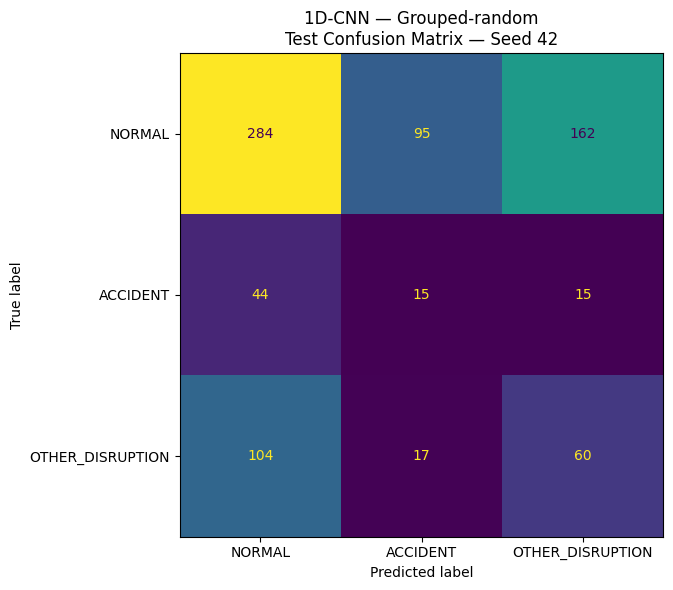

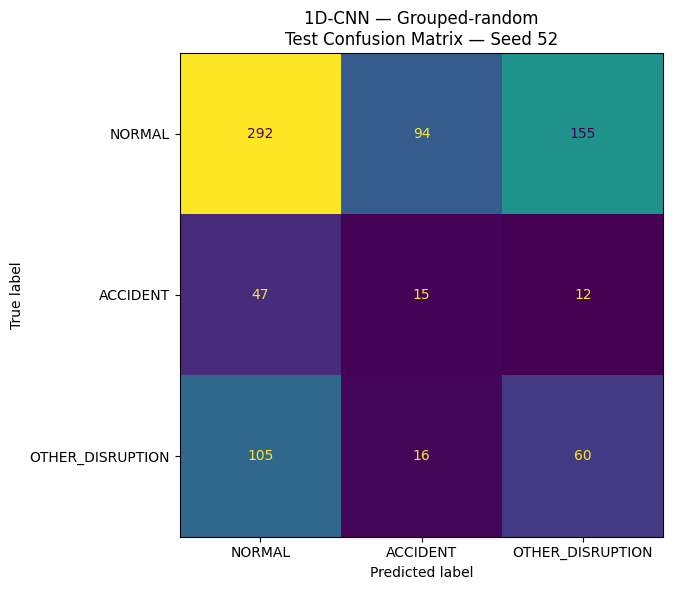

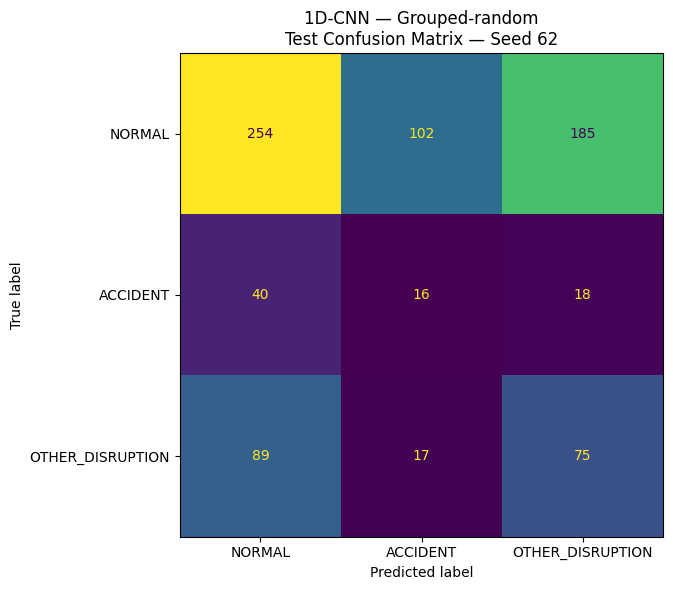

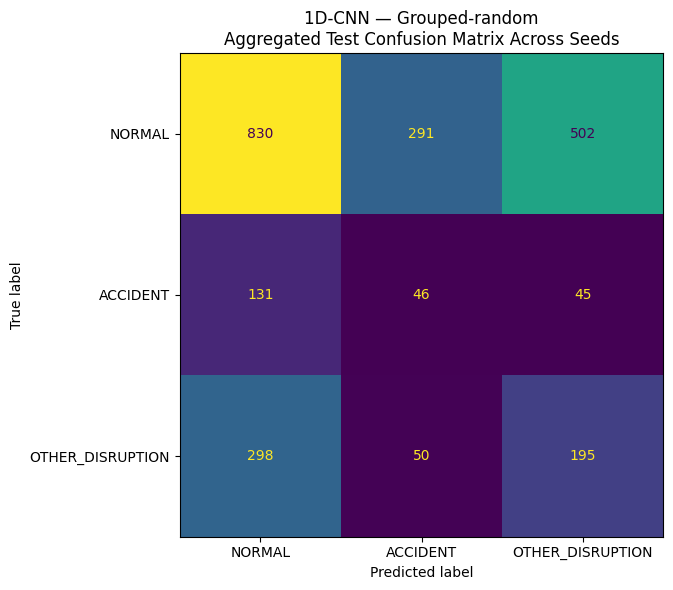

In [22]:
grouped_results = run_cnn_experiment(
    split_name="Grouped-random",
    manifest=grouped_manifest,
    output_prefix="cnn_1d_grouped_random",
)

## 8. Spatial holdout experiment

The spatial split is stricter because each station belongs to only one partition. Validation and test stations are unseen during model training.


Spatial holdout
Train / validation / test: 3703 806 756


target_class,NORMAL,ACCIDENT,OTHER_DISRUPTION
split,,,
train,2517,347,839
validation,549,84,173
test,515,74,167



--- Training seed 42 ---
Spatial holdout | seed=42 | epoch=01 | loss=1.1012 | val_macro_f1=0.3209
Spatial holdout | seed=42 | epoch=05 | loss=1.0978 | val_macro_f1=0.2935
Spatial holdout | seed=42 | epoch=10 | loss=1.0954 | val_macro_f1=0.2381
Early stopping at epoch 10; best epoch = 4.

--- Training seed 52 ---
Spatial holdout | seed=52 | epoch=01 | loss=1.1003 | val_macro_f1=0.2329
Spatial holdout | seed=52 | epoch=05 | loss=1.0968 | val_macro_f1=0.3488
Spatial holdout | seed=52 | epoch=10 | loss=1.0953 | val_macro_f1=0.2501
Spatial holdout | seed=52 | epoch=11 | loss=1.0946 | val_macro_f1=0.3272
Early stopping at epoch 11; best epoch = 5.

--- Training seed 62 ---
Spatial holdout | seed=62 | epoch=01 | loss=1.1016 | val_macro_f1=0.2145
Spatial holdout | seed=62 | epoch=05 | loss=1.0976 | val_macro_f1=0.3424
Spatial holdout | seed=62 | epoch=10 | loss=1.0954 | val_macro_f1=0.3466
Spatial holdout | seed=62 | epoch=15 | loss=1.0957 | val_macro_f1=0.2901
Spatial holdout | seed=62 | epo

,seed,best_epoch,best_val_macro_f1,accuracy,macro_precision,macro_recall,macro_f1,balanced_accuracy
0,42,4,0.339671,0.392857,0.352157,0.364333,0.318059,0.364333
1,52,5,0.348808,0.391534,0.348523,0.358290,0.315252,0.358290
2,62,10,0.346551,0.570106,0.358046,0.347210,0.341649,0.347210



Mean ± SD across seeds:


,split_scheme,metric,mean,std
0,Spatial holdout,accuracy,0.451499,0.102719
1,Spatial holdout,macro_precision,0.352909,0.004806
2,Spatial holdout,macro_recall,0.356611,0.008684
3,Spatial holdout,macro_f1,0.324987,0.014498
4,Spatial holdout,balanced_accuracy,0.356611,0.008684



Per-class test metrics by seed:


,seed,class,precision,recall,f1,support
0,42,NORMAL,0.686131,0.365049,0.476553,515
1,42,ACCIDENT,0.123457,0.135135,0.129032,74
2,42,OTHER_DISRUPTION,0.246883,0.592814,0.348592,167
3,52,NORMAL,0.692029,0.370874,0.482933,515
4,52,ACCIDENT,0.108696,0.135135,0.120482,74
5,52,OTHER_DISRUPTION,0.244845,0.568862,0.342342,167
6,62,NORMAL,0.679727,0.774757,0.724138,515
7,62,ACCIDENT,0.108696,0.135135,0.120482,74
8,62,OTHER_DISRUPTION,0.285714,0.131737,0.180328,167



Per-class test metrics — Mean ± SD across seeds:


class precision              recall                  f1          
                         mean       std      mean       std      mean       std
0          ACCIDENT  0.113616  0.008522  0.135135  0.000000  0.123332  0.004937
1            NORMAL  0.685963  0.006153  0.503560  0.234882  0.561208  0.141138
2  OTHER_DISRUPTION  0.259147  0.023030  0.431138  0.259565  0.290421  0.095394

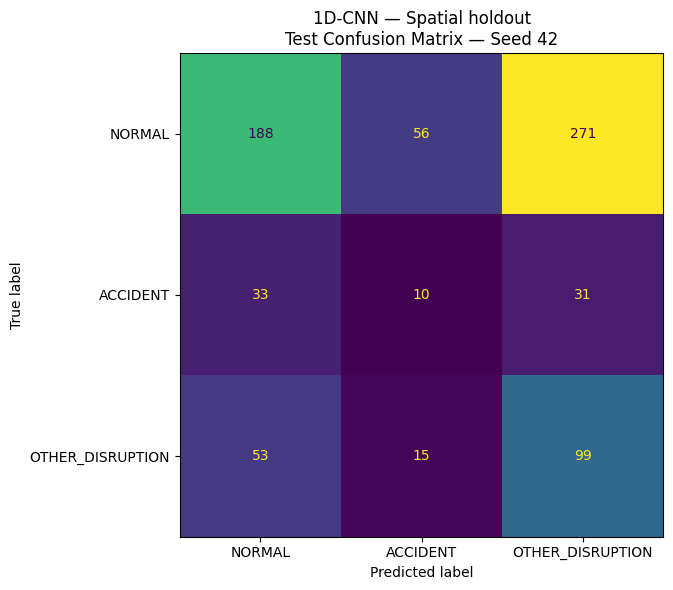

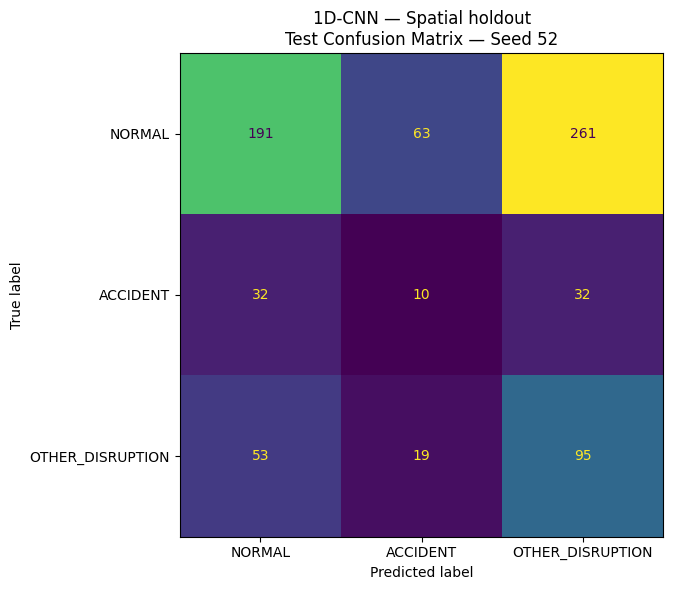

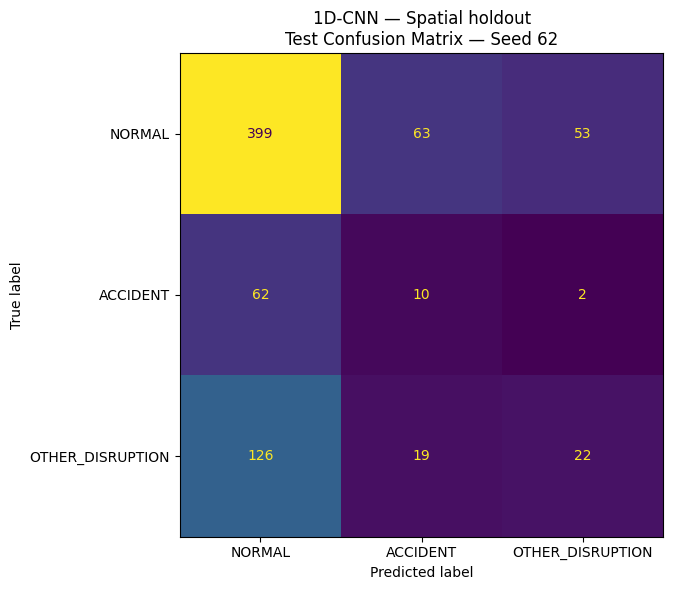

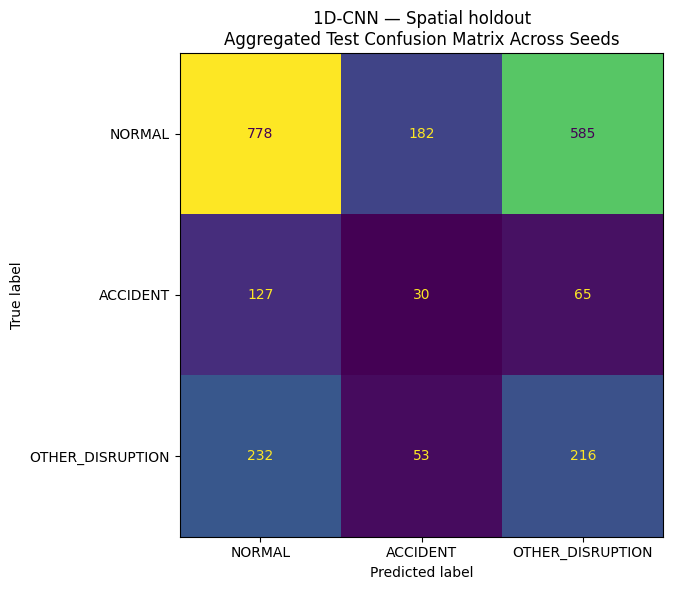

In [23]:
spatial_results = run_cnn_experiment(
    split_name="Spatial holdout",
    manifest=spatial_manifest,
    output_prefix="cnn_1d_spatial",
)

## 9. Final Comparison

Macro-F1 is the primary evaluation metric.

The spatial generalisation gap is calculated as:

$$
\text{Spatial Generalisation Gap}
=
\text{Macro-F1}_{\text{grouped}}
-
\text{Macro-F1}_{\text{spatial}}
$$

A positive value indicates that model performance decreases when evaluated on unseen stations.

In [ ]:
# ------------------------------------------------------------
# Combine overall metrics from both split schemes
# ------------------------------------------------------------

all_metrics = pd.concat(
    [
        grouped_results["metrics"],
        spatial_results["metrics"],
    ],
    ignore_index=True,
)

all_metrics.to_csv(
    OUTPUT_DIR / "cnn_1d_all_metrics_per_seed.csv",
    index=False,
)


# ------------------------------------------------------------
# Overall test metrics
# ------------------------------------------------------------

test_metrics = all_metrics[
    all_metrics["partition"].eq("test")
].copy()

final_summary = (
    test_metrics
    .groupby("split_scheme")[
        [
            "accuracy",
            "macro_precision",
            "macro_recall",
            "macro_f1",
            "balanced_accuracy",
        ]
    ]
    .agg(["mean", "std"])
)

print("=" * 80)
print("FINAL TEST COMPARISON")
print("=" * 80)

display(final_summary)

final_summary.to_csv(
    OUTPUT_DIR / "cnn_1d_final_test_summary.csv",
)


# ------------------------------------------------------------
# Combine per-class metrics from both split schemes
# ------------------------------------------------------------

all_per_class = pd.concat(
    [
        grouped_results["per_class"],
        spatial_results["per_class"],
    ],
    ignore_index=True,
)

all_per_class.to_csv(
    OUTPUT_DIR / "cnn_1d_all_per_class_metrics.csv",
    index=False,
)


# ------------------------------------------------------------
# Per-class test performance
# ------------------------------------------------------------

test_per_class = all_per_class[
    all_per_class["partition"].eq("test")
].copy()

final_per_class_summary = (
    test_per_class
    .groupby(
        [
            "split_scheme",
            "class",
        ]
    )[
        [
            "precision",
            "recall",
            "f1",
        ]
    ]
    .agg(["mean", "std"])
)

print("\n" + "=" * 80)
print("FINAL PER-CLASS TEST COMPARISON")
print("=" * 80)

display(final_per_class_summary)

final_per_class_summary.to_csv(
    OUTPUT_DIR / "cnn_1d_final_per_class_summary.csv",
)


# ------------------------------------------------------------
# Spatial generalisation gap
# ------------------------------------------------------------

grouped_macro_f1 = test_metrics.loc[
    test_metrics["split_scheme"].eq("Grouped-random"),
    "macro_f1",
].mean()

spatial_macro_f1 = test_metrics.loc[
    test_metrics["split_scheme"].eq("Spatial holdout"),
    "macro_f1",
].mean()

spatial_generalisation_gap = (
    grouped_macro_f1
    - spatial_macro_f1
)

print("\n" + "=" * 80)
print("SPATIAL GENERALISATION GAP")
print("=" * 80)

print(
    f"Grouped-random mean Macro-F1 : "
    f"{grouped_macro_f1:.4f}"
)

print(
    f"Spatial holdout mean Macro-F1: "
    f"{spatial_macro_f1:.4f}"
)

print(
    f"\nSpatial generalisation gap "
    f"(Grouped Macro-F1 - Spatial Macro-F1): "
    f"{spatial_generalisation_gap:.4f}"
)


# ------------------------------------------------------------
# Interpretation of the spatial generalisation gap
# ------------------------------------------------------------

if spatial_generalisation_gap > 0:
    print(
        "\nInterpretation: Performance is lower on unseen stations "
        "than under the grouped-random split."
    )

elif spatial_generalisation_gap < 0:
    print(
        "\nInterpretation: Performance is higher on the spatial "
        "holdout than under the grouped-random split."
    )

else:
    print(
        "\nInterpretation: Mean Macro-F1 is identical across "
        "the two split schemes."
    )


# ------------------------------------------------------------
# Save spatial generalisation gap
# ------------------------------------------------------------

gap_df = pd.DataFrame(
    {
        "model": ["1D-CNN"],
        "grouped_random_macro_f1": [
            grouped_macro_f1
        ],
        "spatial_holdout_macro_f1": [
            spatial_macro_f1
        ],
        "spatial_generalisation_gap": [
            spatial_generalisation_gap
        ],
    }
)

gap_df.to_csv(
    OUTPUT_DIR
    / "cnn_1d_spatial_generalisation_gap.csv",
    index=False,
)


# ------------------------------------------------------------
# Display saved output files
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("SAVED OUTPUT FILES")
print("=" * 80)

for path in sorted(OUTPUT_DIR.iterdir()):
    print("-", path.name)

FINAL TEST COMPARISON


accuracy           macro_precision           macro_recall            macro_f1           balanced_accuracy          
                     mean       std            mean       std         mean       std      mean       std              mean       std
split_scheme                                                                                                                        
Grouped-random   0.448492  0.013989        0.346905  0.003818     0.359241  0.006909  0.343061  0.002948          0.359241  0.006909
Spatial holdout  0.451499  0.102719        0.352909  0.004806     0.356611  0.008684  0.324987  0.014498          0.356611  0.008684


FINAL PER-CLASS TEST COMPARISON


precision              recall                  f1          
                                      mean       std      mean       std      mean       std
split_scheme    class                                                                       
Grouped-random  ACCIDENT          0.118876  0.000994  0.207207  0.007802  0.151039  0.001944
                NORMAL            0.659417  0.003266  0.511399  0.037030  0.575480  0.022717
                OTHER_DISRUPTION  0.262422  0.008470  0.359116  0.047847  0.302665  0.021193
Spatial holdout ACCIDENT          0.113616  0.008522  0.135135  0.000000  0.123332  0.004937
                NORMAL            0.685963  0.006153  0.503560  0.234882  0.561208  0.141138
                OTHER_DISRUPTION  0.259147  0.023030  0.431138  0.259565  0.290421  0.095394


SPATIAL GENERALISATION GAP
Grouped-random mean Macro-F1 : 0.3431
Spatial holdout mean Macro-F1: 0.3250

Spatial generalisation gap (Grouped Macro-F1 - Spatial Macro-F1): 0.0181

Interpretation: Performance is lower on unseen stations than under the grouped-random split.

SAVED OUTPUT FILES
- cnn_1d_all_metrics_per_seed.csv
- cnn_1d_all_per_class_metrics.csv
- cnn_1d_final_per_class_summary.csv
- cnn_1d_final_test_summary.csv
- cnn_1d_spatial_generalisation_gap.csv


## Interpretation guidance

Focus on:

- mean test **Macro-F1** across the three seeds;
- standard deviation across seeds;
- balanced accuracy;
- per-class recall and F1;
- the confusion matrix, especially `NORMAL → OTHER_DISRUPTION` and `ACCIDENT → OTHER_DISRUPTION`;
- the performance gap between grouped-random and spatial holdout evaluation.

The 1D-CNN uses the seven-hour traffic sequence directly, allowing temporal patterns to be captured and compared with the performance of the classical baseline models.